In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.interpolate import CubicSpline
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#f8f9fa",
    "axes.grid": True, "grid.alpha": 0.4, "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
})

def show_plot(name):
    plt.tight_layout()
    plt.show()
    print(f"  → displayed {name}")

DATASET_PATH = r"C:\Users\PAVAN\OneDrive\ドキュメント\fin\dataset.csv"
SEP = "─" * 65

# =============================================================================
# RAW DATA OVERVIEW
# =============================================================================
print(f"\n{SEP}")
print("SECTION 1 — RAW DATA OVERVIEW")
print(SEP)

df = pd.read_csv(DATASET_PATH)
df["datetime"] = pd.to_datetime(df["datetime"], dayfirst=True)
df = df.sort_values("datetime").reset_index(drop=True)

option_cols = [c for c in df.columns if c not in ["datetime","underlying_price"]]
n_ts        = df["datetime"].nunique()
n_opts      = len(option_cols)
n_cells     = n_ts * n_opts
n_missing   = df[option_cols].isna().sum().sum()
n_observed  = n_cells - n_missing

print(f"\n  Shape (wide)        : {df.shape}")
print(f"  Timestamps          : {n_ts}")
print(f"  Option columns      : {n_opts}")
print(f"  Total cells         : {n_cells:,}")
print(f"  Observed cells      : {n_observed:,}  ({n_observed/n_cells*100:.1f}%)")
print(f"  Missing cells       : {n_missing:,}   ({n_missing/n_cells*100:.1f}%)")
print(f"\n  Date range          : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"  Spot price range    : {df['underlying_price'].min():.1f} → {df['underlying_price'].max():.1f}")
print(f"  Spot price mean     : {df['underlying_price'].mean():.1f}")

# Parse option columns
_pat = re.compile(r"NIFTY(\d{2}[A-Z]{3}\d{2})(\d+)(CE|PE)")
ce_cols = [c for c in option_cols if c.endswith("CE")]
pe_cols = [c for c in option_cols if c.endswith("PE")]
strikes_ce = sorted(set(int(_pat.match(c).group(2)) for c in ce_cols if _pat.match(c)))
strikes_pe = sorted(set(int(_pat.match(c).group(2)) for c in pe_cols if _pat.match(c)))

print(f"\n  CE strikes ({len(ce_cols)}): {strikes_ce[0]} → {strikes_ce[-1]}")
print(f"  PE strikes ({len(pe_cols)}): {strikes_pe[0]} → {strikes_pe[-1]}")

# Melt to long format
df_long = df.melt(id_vars=["datetime","underlying_price"],
                  value_vars=option_cols, var_name="option_col", value_name="iv")
parsed = df_long["option_col"].apply(
    lambda c: pd.Series(
        (lambda m: (int(m.group(2)), m.group(3)) if m else (None,None))(_pat.match(c)),
        index=["strike","option_type"]
    )
)
df_long = pd.concat([df_long, parsed], axis=1).dropna(subset=["strike"])
df_long["strike"] = df_long["strike"].astype(int)
df_long["log_moneyness"] = np.log(df_long["strike"] / df_long["underlying_price"])
df_long = df_long.sort_values(["datetime","strike"]).reset_index(drop=True)
obs = df_long[df_long["iv"].notna()]



─────────────────────────────────────────────────────────────────
SECTION 1 — RAW DATA OVERVIEW
─────────────────────────────────────────────────────────────────

  Shape (wide)        : (975, 30)
  Timestamps          : 975
  Option columns      : 28
  Total cells         : 27,300
  Observed cells      : 21,840  (80.0%)
  Missing cells       : 5,460   (20.0%)

  Date range          : 2026-01-07 09:15:00 → 2026-01-27 15:25:00
  Spot price range    : 24940.7 → 26183.8
  Spot price mean     : 25564.2

  CE strikes (14): 25200 → 26500
  PE strikes (14): 23800 → 25100



─────────────────────────────────────────────────────────────────
SECTION 2 — IV DISTRIBUTION
─────────────────────────────────────────────────────────────────

  Percentile       IV Value
  ──────────────────────────
  p0.1              0.08189
  p1                0.08788
  p5                0.09488
  p25               0.11004
  p50               0.13062
  p75               0.16856
  p95               0.49462
  p99               1.13811
  p99.9             2.61665

  Mean   : 0.18294
  Std    : 0.21908
  Skew   : 7.457  (>0 = right tail, expect positive for IV)
  Kurt   : 87.342  (>0 = fat tails)

  CE IV mean : 0.16693  |  PE IV mean : 0.19906
  CE IV std  : 0.21752  |  PE IV std  : 0.21947
  PE > CE by : 3.21 vol points (expect positive — put skew)


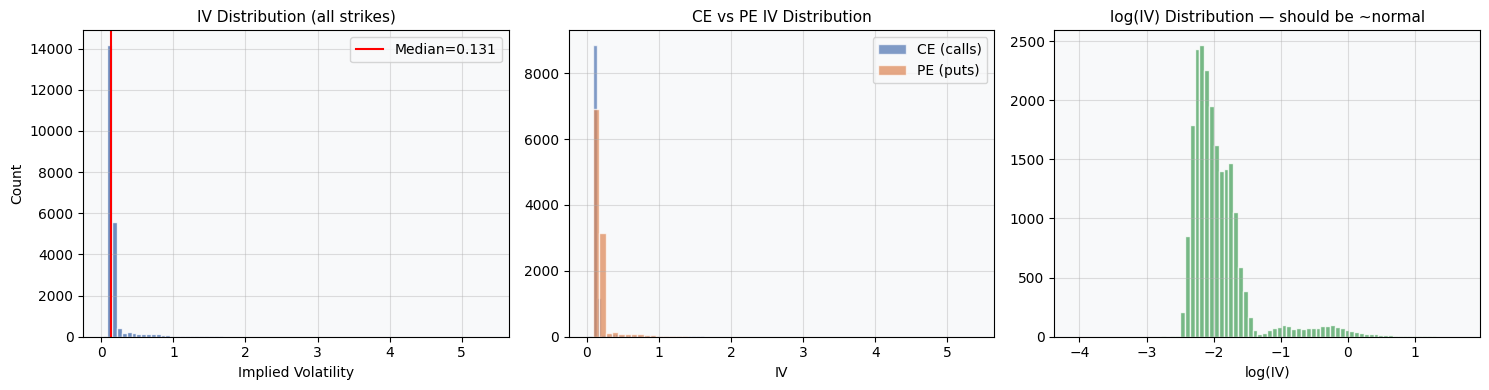

  → displayed 01_iv_distribution


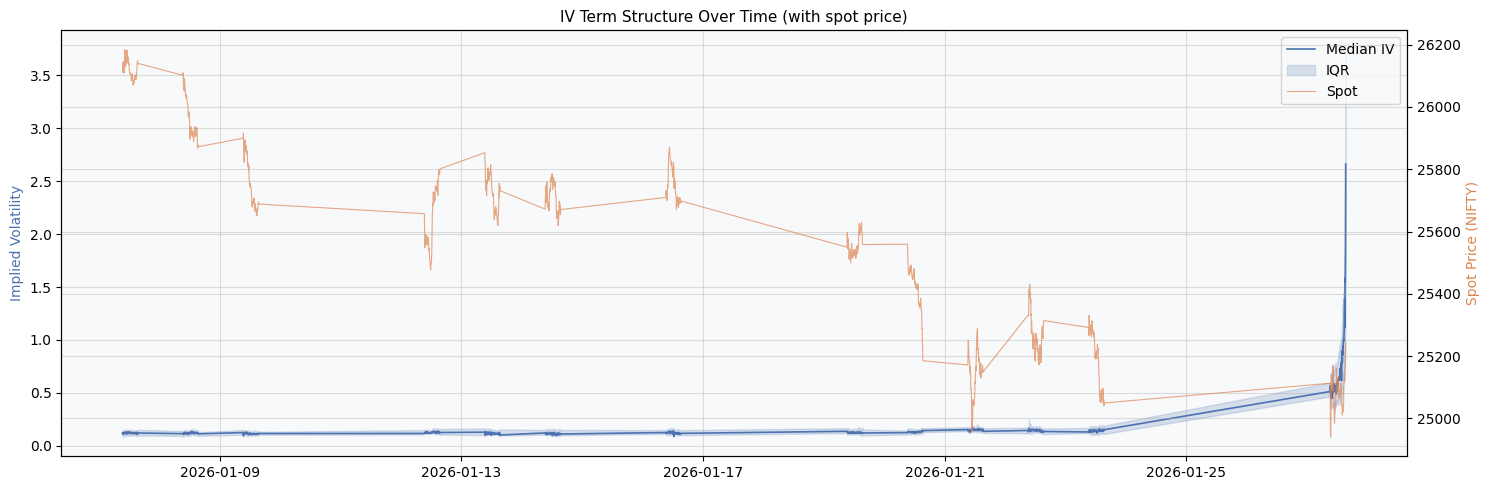

  → displayed 02_iv_over_time


In [ ]:
# =============================================================================
#  IV DISTRIBUTION ANALYSIS
# =============================================================================
print(f"\n{SEP}")
print("SECTION 2 — IV DISTRIBUTION")
print(SEP)

iv_vals = obs["iv"]
pcts = [0.1,1,5,25,50,75,95,99,99.9]
print(f"\n  {'Percentile':<14} {'IV Value':>10}")
print(f"  {'─'*26}")
for p in pcts:
    print(f"  p{p:<13} {np.percentile(iv_vals,p):>10.5f}")

print(f"\n  Mean   : {iv_vals.mean():.5f}")
print(f"  Std    : {iv_vals.std():.5f}")
print(f"  Skew   : {iv_vals.skew():.3f}  (>0 = right tail, expect positive for IV)")
print(f"  Kurt   : {iv_vals.kurt():.3f}  (>0 = fat tails)")

ce_iv = obs[obs["option_type"]=="CE"]["iv"]
pe_iv = obs[obs["option_type"]=="PE"]["iv"]
print(f"\n  CE IV mean : {ce_iv.mean():.5f}  |  PE IV mean : {pe_iv.mean():.5f}")
print(f"  CE IV std  : {ce_iv.std():.5f}  |  PE IV std  : {pe_iv.std():.5f}")
print(f"  PE > CE by : {(pe_iv.mean()-ce_iv.mean())*100:.2f} vol points (expect positive — put skew)")

# Figure 1: IV distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(iv_vals, bins=80, color="#4C72B0", alpha=0.8, edgecolor="white")
axes[0].set_title("IV Distribution (all strikes)")
axes[0].set_xlabel("Implied Volatility"); axes[0].set_ylabel("Count")
axes[0].axvline(iv_vals.median(), color="red", lw=1.5, label=f"Median={iv_vals.median():.3f}")
axes[0].legend()

axes[1].hist(ce_iv, bins=60, alpha=0.7, color="#4C72B0", label="CE (calls)", edgecolor="white")
axes[1].hist(pe_iv, bins=60, alpha=0.7, color="#DD8452", label="PE (puts)", edgecolor="white")
axes[1].set_title("CE vs PE IV Distribution"); axes[1].set_xlabel("IV"); axes[1].legend()

axes[2].hist(np.log(iv_vals), bins=80, color="#55A868", alpha=0.8, edgecolor="white")
axes[2].set_title("log(IV) Distribution — should be ~normal")
axes[2].set_xlabel("log(IV)")
show_plot("01_iv_distribution")

# Figure 2: IV over time (spot overlay)
fig, ax1 = plt.subplots(figsize=(15, 5))
ts_median_iv = obs.groupby("datetime")["iv"].median()
ax1.plot(ts_median_iv.index, ts_median_iv.values, color="#4C72B0", lw=1.2, label="Median IV")
ax1.fill_between(
    obs.groupby("datetime")["iv"].quantile(0.25).index,
    obs.groupby("datetime")["iv"].quantile(0.25).values,
    obs.groupby("datetime")["iv"].quantile(0.75).values,
    alpha=0.2, color="#4C72B0", label="IQR"
)
ax1.set_ylabel("Implied Volatility", color="#4C72B0")
ax1.set_title("IV Term Structure Over Time (with spot price)")
ax2 = ax1.twinx()
ax2.plot(df["datetime"], df["underlying_price"], color="#DD8452", lw=0.8, alpha=0.7, label="Spot")
ax2.set_ylabel("Spot Price (NIFTY)", color="#DD8452")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")
show_plot("02_iv_over_time")


─────────────────────────────────────────────────────────────────
SECTION 3 — MISSING DATA ANALYSIS
─────────────────────────────────────────────────────────────────

  Missing % per timestamp:
    Mean   : 5.6 columns (20.0%)
    Max    : 14 columns  (timestamp: 2026-01-16 09:55:00)
    Min    : 0 columns
    Fully observed timestamps : 3
    >50% missing timestamps   : 0

  Top 10 most-missing columns:
    K=24200 PE            22.3%  ██████
    K=26400 CE            21.8%  ██████
    K=25800 CE            21.5%  ██████
    K=26200 CE            21.4%  ██████
    K=24800 PE            21.4%  ██████
    K=24000 PE            21.4%  ██████
    K=25100 PE            21.0%  ██████
    K=23800 PE            20.8%  ██████
    K=25400 CE            20.7%  ██████
    K=24400 PE            20.7%  ██████

  Missing pattern by option type:
    CE missing: 19.7%  |  PE missing: 20.3%

  Missing % by strike (CE — showing ITM/ATM/OTM pattern):
    K=25200  (ITM)  19.9%  ███
    K=25300  (ITM)  18

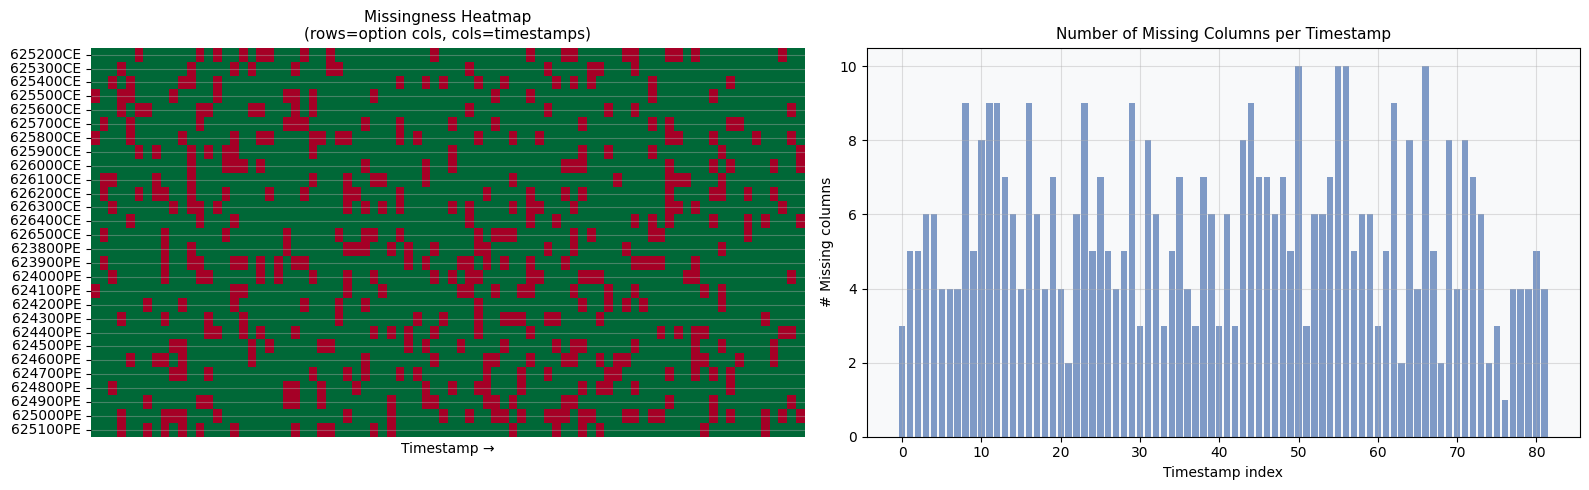

  → displayed 03_missingness


In [ ]:

# =============================================================================
#  MISSING DATA ANALYSIS
# =============================================================================
print(f"\n{SEP}")
print(" MISSING DATA ANALYSIS")
print(SEP)

miss_by_col = df[option_cols].isna().mean().sort_values(ascending=False)
miss_by_ts  = df[option_cols].isna().sum(axis=1)

print(f"\n  Missing % per timestamp:")
print(f"    Mean   : {miss_by_ts.mean():.1f} columns ({miss_by_ts.mean()/n_opts*100:.1f}%)")
print(f"    Max    : {miss_by_ts.max()} columns  (timestamp: {df.loc[miss_by_ts.idxmax(),'datetime']})")
print(f"    Min    : {miss_by_ts.min()} columns")
print(f"    Fully observed timestamps : {(miss_by_ts==0).sum()}")
print(f"    >50% missing timestamps   : {(miss_by_ts>n_opts*0.5).sum()}")

print(f"\n  Top 10 most-missing columns:")
for col, pct in miss_by_col.head(10).items():
    m = _pat.match(col)
    tag = f"K={m.group(2)} {m.group(3)}" if m else col
    bar = "█" * int(pct*30)
    print(f"    {tag:<20} {pct*100:5.1f}%  {bar}")

print(f"\n  Missing pattern by option type:")
ce_miss = df[ce_cols].isna().mean().mean()
pe_miss = df[pe_cols].isna().mean().mean()
print(f"    CE missing: {ce_miss*100:.1f}%  |  PE missing: {pe_miss*100:.1f}%")

# Missing by moneyness zone
miss_by_col_df = pd.DataFrame({
    "col": miss_by_col.index, "miss_pct": miss_by_col.values
})
miss_by_col_df["strike"] = miss_by_col_df["col"].apply(
    lambda c: int(_pat.match(c).group(2)) if _pat.match(c) else None
)
miss_by_col_df["otype"] = miss_by_col_df["col"].apply(
    lambda c: _pat.match(c).group(3) if _pat.match(c) else None
)
print(f"\n  Missing % by strike (CE — showing ITM/ATM/OTM pattern):")
spot_mid = df["underlying_price"].median()
for _, row in miss_by_col_df[miss_by_col_df["otype"]=="CE"].sort_values("strike").iterrows():
    zone = "ATM" if abs(row["strike"]-spot_mid)<300 else ("ITM" if row["strike"]<spot_mid else "OTM")
    bar = "█" * int(row["miss_pct"]*20)
    print(f"    K={int(row['strike']):<6} ({zone:<3}) {row['miss_pct']*100:5.1f}%  {bar}")

# Figure 3: Missingness heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
miss_matrix = df[option_cols].isna().astype(int)
# Downsample rows if too many timestamps
step = max(1, len(miss_matrix)//80)
sns.heatmap(miss_matrix.iloc[::step].T, ax=axes[0],
            cmap="RdYlGn_r", cbar=False, xticklabels=False,
            yticklabels=[c[-8:] for c in option_cols])
axes[0].set_title("Missingness Heatmap\n(rows=option cols, cols=timestamps)")
axes[0].set_xlabel("Timestamp →")

axes[1].bar(range(len(miss_by_ts.iloc[::step])),
            miss_by_ts.iloc[::step].values, color="#4C72B0", alpha=0.7)
axes[1].set_title("Number of Missing Columns per Timestamp")
axes[1].set_xlabel("Timestamp index"); axes[1].set_ylabel("# Missing columns")
show_plot("03_missingness")


─────────────────────────────────────────────────────────────────
SECTION 4 — VOLATILITY SMILE AND SKEW
─────────────────────────────────────────────────────────────────

  Smile analysis at 5 timestamps:


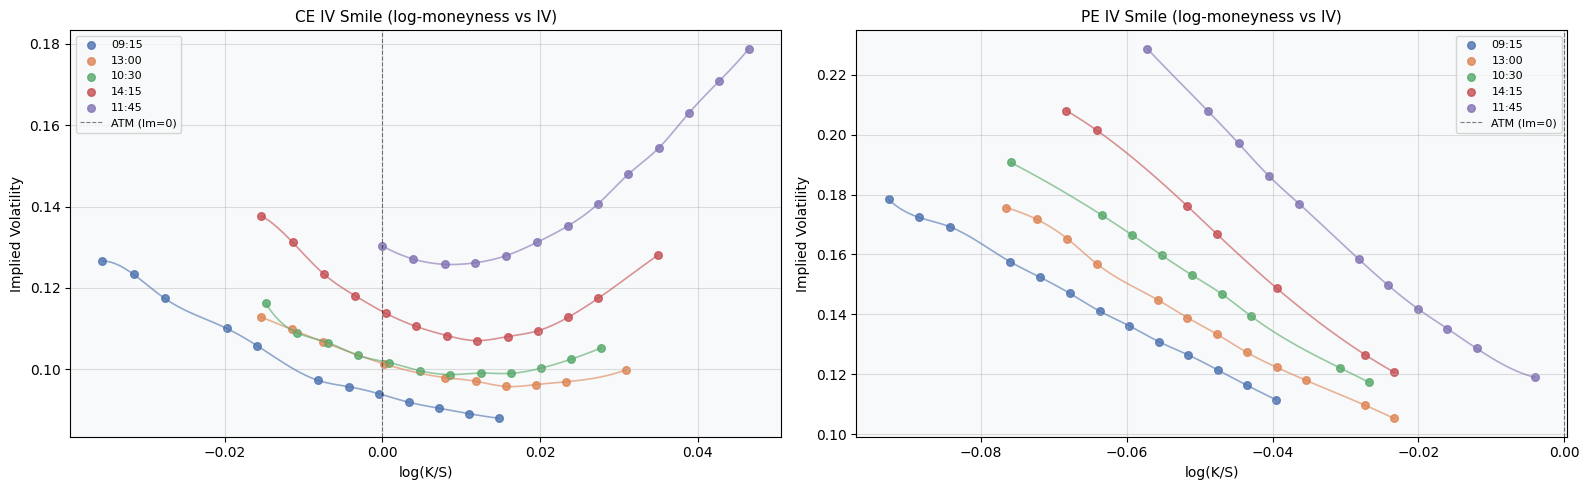

  → displayed 04_volatility_smile

  ATM CE IV   : 0.1207
  ATM PE IV   : 0.1890
  OTM Call IV : 0.2560
  OTM Put IV  : 0.2005
  Put skew (OTM put - ATM CE): 0.0798  (✓ positive as expected)

  Deep OTM put  (lm<-0.04): 0.2011
  Near ATM      (|lm|<0.01): 0.1250
  Deep OTM call (lm>+0.04): 0.4378
  Smile shape: ✓ U-shaped smile


In [ ]:

# =============================================================================
#  VOLATILITY SMILE AND SKEW
# =============================================================================
print(f"\n{SEP}")
print("SECTION 4 — VOLATILITY SMILE AND SKEW")
print(SEP)

# Pick 5 representative timestamps spread across the dataset
sample_ts = df["datetime"].iloc[
    [int(i*len(df)/5) for i in range(5)]
].values

print(f"\n  Smile analysis at {len(sample_ts)} timestamps:")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

for ax, otype in zip(axes, ["CE","PE"]):
    for ts, col in zip(sample_ts, colors):
        ts_data = obs[(obs["datetime"]==ts) & (obs["option_type"]==otype)]
        if len(ts_data) < 3: continue
        ax.scatter(ts_data["log_moneyness"], ts_data["iv"],
                   color=col, s=30, alpha=0.8,
                   label=f"{pd.Timestamp(ts).strftime('%H:%M')}")
        # Fit spline for visual
        ts_s = ts_data.sort_values("log_moneyness")
        if len(ts_s) >= 4:
            try:
                cs = CubicSpline(ts_s["log_moneyness"], ts_s["iv"])
                xr = np.linspace(ts_s["log_moneyness"].min(), ts_s["log_moneyness"].max(), 100)
                ax.plot(xr, cs(xr), color=col, lw=1.2, alpha=0.6)
            except: pass
    ax.axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.5, label="ATM (lm=0)")
    ax.set_title(f"{otype} IV Smile (log-moneyness vs IV)")
    ax.set_xlabel("log(K/S)"); ax.set_ylabel("Implied Volatility")
    ax.legend(fontsize=8)
show_plot("04_volatility_smile")

# Quantify skew
ce_obs = obs[obs["option_type"]=="CE"]
pe_obs = obs[obs["option_type"]=="PE"]
atm_band = 0.02

ce_atm = ce_obs[ce_obs["log_moneyness"].abs() < atm_band]["iv"].mean()
pe_atm = pe_obs[pe_obs["log_moneyness"].abs() < atm_band]["iv"].mean()
ce_otm = ce_obs[ce_obs["log_moneyness"] > 0.02]["iv"].mean()   # OTM call
pe_otm = pe_obs[pe_obs["log_moneyness"] < -0.02]["iv"].mean()  # OTM put

print(f"\n  ATM CE IV   : {ce_atm:.4f}")
print(f"  ATM PE IV   : {pe_atm:.4f}")
print(f"  OTM Call IV : {ce_otm:.4f}")
print(f"  OTM Put IV  : {pe_otm:.4f}")
print(f"  Put skew (OTM put - ATM CE): {(pe_otm - ce_atm):.4f}  "
      f"({'✓ positive as expected' if pe_otm > ce_atm else '⚠ check data'})")

# Smile curvature
all_lm = obs["log_moneyness"]
deep_otm_put  = obs[all_lm < -0.04]["iv"].mean()
near_atm      = obs[all_lm.abs() < 0.01]["iv"].mean()
deep_otm_call = obs[all_lm > 0.04]["iv"].mean()
print(f"\n  Deep OTM put  (lm<-0.04): {deep_otm_put:.4f}")
print(f"  Near ATM      (|lm|<0.01): {near_atm:.4f}")
print(f"  Deep OTM call (lm>+0.04): {deep_otm_call:.4f}")
smile = "✓ U-shaped smile" if (deep_otm_put > near_atm and deep_otm_call > near_atm) else "⚠ check shape"
print(f"  Smile shape: {smile}")



─────────────────────────────────────────────────────────────────
SECTION 5 — TERM STRUCTURE (IV OVER TIME)
─────────────────────────────────────────────────────────────────

  ATM IV statistics over time:
    CE  mean=0.1326  std=0.0920  min=0.0823  max=0.9525  autocorr(1)=0.980
    PE  mean=0.1695  std=0.1272  min=0.0935  max=1.4901  autocorr(1)=0.948

  High autocorrelation (>0.8) means IV is persistent — lag features will be highly informative.

  Intraday IV pattern:
    Open (9:15–10:00) mean IV : 0.1667
    Mid  (11:00–13:00) mean IV: 0.1717
    Close (14:00–15:30) mean IV:0.2171


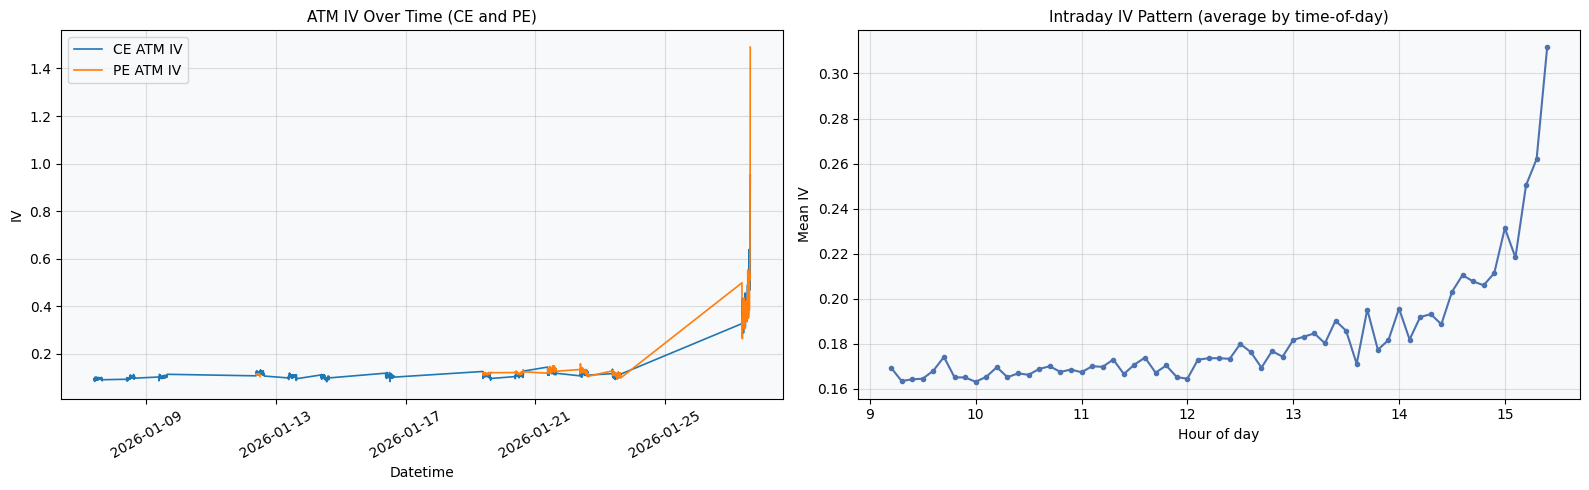

  → displayed 05_term_structure


In [ ]:

# =============================================================================
#  TERM STRUCTURE
# =============================================================================
print(f"\n{SEP}")
print(" TERM STRUCTURE (IV OVER TIME)")
print(SEP)

# ATM IV over time for both CE and PE
atm_iv_ts = (obs[obs["log_moneyness"].abs() < 0.02]
             .groupby(["datetime","option_type"])["iv"]
             .mean().unstack("option_type"))

print(f"\n  ATM IV statistics over time:")
for col in atm_iv_ts.columns:
    s = atm_iv_ts[col].dropna()
    print(f"    {col}  mean={s.mean():.4f}  std={s.std():.4f}  "
          f"min={s.min():.4f}  max={s.max():.4f}  "
          f"autocorr(1)={s.autocorr(1):.3f}")

print(f"\n  High autocorrelation (>0.8) means IV is persistent — "
      f"lag features will be highly informative.")

# Intraday pattern
obs_copy = obs.copy()
obs_copy["tod"] = obs_copy["datetime"].dt.hour + obs_copy["datetime"].dt.minute/60
tod_iv = obs_copy.groupby(obs_copy["tod"].round(1))["iv"].mean()
print(f"\n  Intraday IV pattern:")
print(f"    Open (9:15–10:00) mean IV : {obs_copy[obs_copy['tod']<10]['iv'].mean():.4f}")
print(f"    Mid  (11:00–13:00) mean IV: {obs_copy[(obs_copy['tod']>=11)&(obs_copy['tod']<13)]['iv'].mean():.4f}")
print(f"    Close (14:00–15:30) mean IV:{obs_copy[obs_copy['tod']>=14]['iv'].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for col in atm_iv_ts.columns:
    axes[0].plot(atm_iv_ts.index, atm_iv_ts[col], label=f"{col} ATM IV", lw=1.2)
axes[0].set_title("ATM IV Over Time (CE and PE)")
axes[0].set_xlabel("Datetime"); axes[0].set_ylabel("IV")
axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(tod_iv.index, tod_iv.values, color="#4C72B0", lw=1.5, marker="o", markersize=3)
axes[1].set_title("Intraday IV Pattern (average by time-of-day)")
axes[1].set_xlabel("Hour of day"); axes[1].set_ylabel("Mean IV")
show_plot("05_term_structure")



─────────────────────────────────────────────────────────────────
SECTION 6 — SPOT PRICE AND IV CORRELATION
─────────────────────────────────────────────────────────────────

  Spot price statistics:
    Mean  : 25564.16
    Std   : 317.64
    Return std (5-min): 0.0833%
    Annualised vol from returns: 11.45%

  Spot return vs ATM CE IV correlation: 0.0651
  (Negative expected — when spot drops, IV rises = put skew)


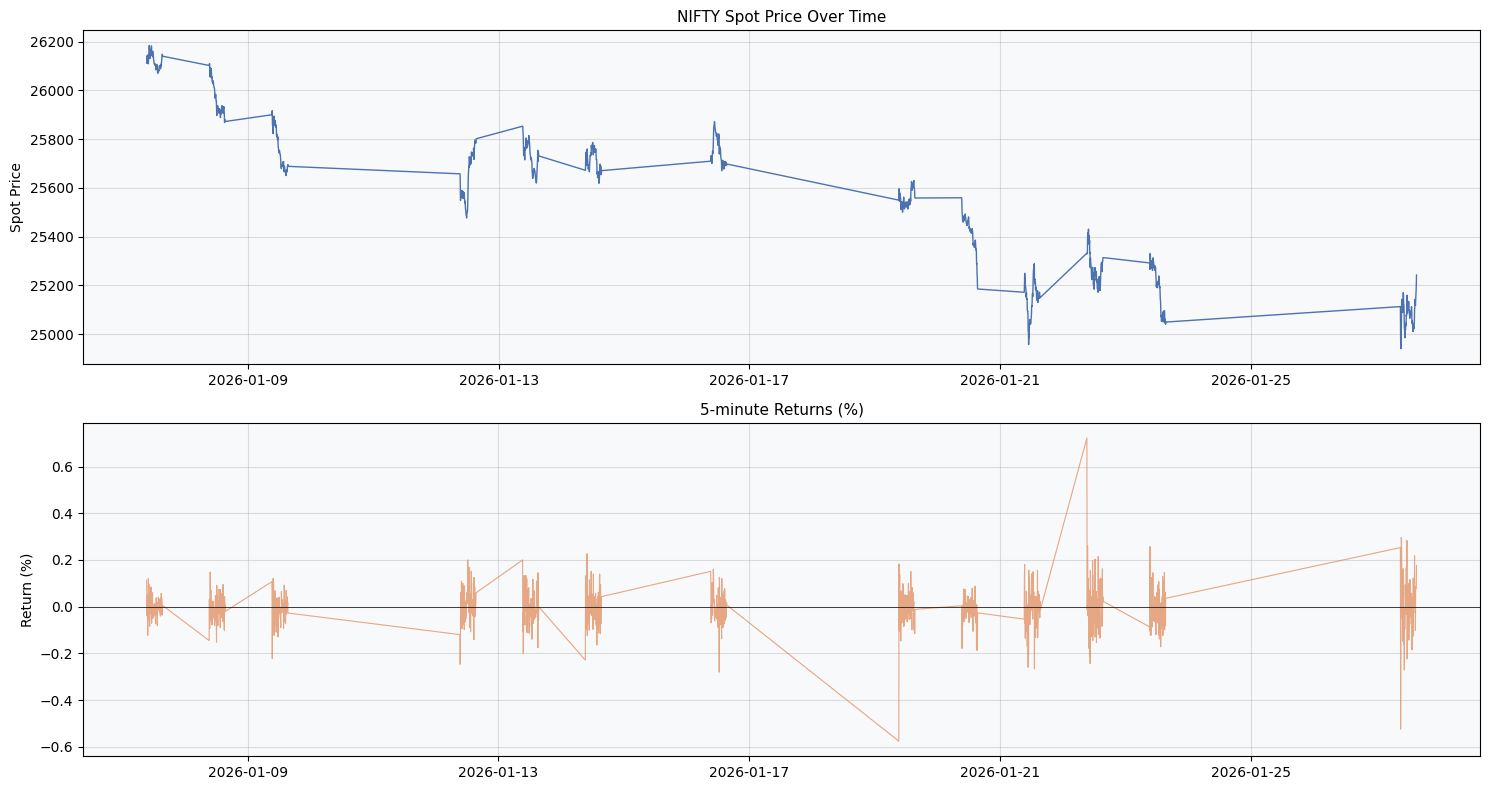

  → displayed 06_spot_dynamics


In [ ]:

# =============================================================================
#  SPOT PRICE DYNAMICS
# =============================================================================
print(f"\n{SEP}")
print(" SPOT PRICE AND IV CORRELATION")
print(SEP)

spot = df.set_index("datetime")["underlying_price"]
spot_ret = spot.pct_change().dropna()
atm_iv_ce = atm_iv_ts["CE"].dropna() if "CE" in atm_iv_ts.columns else pd.Series(dtype=float)

print(f"\n  Spot price statistics:")
print(f"    Mean  : {spot.mean():.2f}")
print(f"    Std   : {spot.std():.2f}")
print(f"    Return std (5-min): {spot_ret.std()*100:.4f}%")
print(f"    Annualised vol from returns: "
      f"{spot_ret.std()*np.sqrt(252*75)*100:.2f}%")

if len(atm_iv_ce) > 10:
    aligned = pd.concat([spot_ret.rename("ret"), atm_iv_ce.rename("iv")],
                        axis=1).dropna()
    if len(aligned) > 5:
        corr = aligned.corr().iloc[0,1]
        print(f"\n  Spot return vs ATM CE IV correlation: {corr:.4f}")
        print(f"  (Negative expected — when spot drops, IV rises = put skew)")

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(spot.index, spot.values, color="#4C72B0", lw=1)
axes[0].set_title("NIFTY Spot Price Over Time")
axes[0].set_ylabel("Spot Price")
axes[1].plot(spot_ret.index, spot_ret.values*100, color="#DD8452", lw=0.8, alpha=0.7)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("5-minute Returns (%)")
axes[1].set_ylabel("Return (%)")
show_plot("06_spot_dynamics")



In [ ]:

# =============================================================================
# DATA QUALITY CHECKS
# =============================================================================
print(f"\n{SEP}")
print(" DATA QUALITY")
print(SEP)

# Put-call parity divergence
piv = obs[obs["option_type"]=="PE"].set_index(["datetime","strike"])["iv"].rename("iv_pe")
civ = obs[obs["option_type"]=="CE"].set_index(["datetime","strike"])["iv"].rename("iv_ce")
pc = pd.concat([piv, civ], axis=1).dropna()
divergence = (pc["iv_pe"] - pc["iv_ce"]).abs()

print(f"\n  Put-Call IV divergence (same strike, same timestamp):")
print(f"    Pairs checked  : {len(pc):,}")
print(f"    Mean |PE-CE|   : {divergence.mean():.5f}")
print(f"    Max  |PE-CE|   : {divergence.max():.5f}")
print(f"    >0.05 pairs    : {(divergence>0.05).sum():,}  "
      f"({(divergence>0.05).mean()*100:.1f}%) — potential data issues")
print(f"    >0.10 pairs    : {(divergence>0.10).sum():,}  "
      f"({(divergence>0.10).mean()*100:.1f}%) — likely errors")

# Outlier detection
p01, p99 = np.percentile(iv_vals, 0.1), np.percentile(iv_vals, 99.9)
outliers = obs[(obs["iv"] < p01) | (obs["iv"] > p99)]
print(f"\n  Outliers (outside p0.1={p01:.4f}, p99.9={p99:.4f}):")
print(f"    Count : {len(outliers)} ({len(outliers)/len(obs)*100:.2f}%)")
if len(outliers) > 0:
    print(f"    Min   : {outliers['iv'].min():.5f}")
    print(f"    Max   : {outliers['iv'].max():.5f}")

# Stale value detection (IV unchanged across 3+ consecutive timestamps)
stale_count = 0
for col in option_cols[:10]:  # check first 10 cols as sample
    s = df[col].dropna()
    if len(s) >= 3:
        diffs = s.diff().abs()
        stale = (diffs == 0).sum()
        stale_count += stale
print(f"\n  Stale values (unchanged across consecutive timestamps, sample 10 cols):")
print(f"    Count : {stale_count}")

# Temporal gap check
ts_diffs = df["datetime"].diff().dropna()
expected_gap = ts_diffs.mode()[0]
gaps = ts_diffs[ts_diffs > expected_gap * 2]
print(f"\n  Timestamp gaps:")
print(f"    Expected interval : {expected_gap}")
print(f"    Irregular gaps    : {len(gaps)}")
if len(gaps) > 0:
    print(f"    Gap timestamps    :")
    for ts, gap in gaps.items():
        print(f"      {df.loc[ts,'datetime']}  (gap = {gap})")



─────────────────────────────────────────────────────────────────
SECTION 7 — DATA QUALITY
─────────────────────────────────────────────────────────────────

  Put-Call IV divergence (same strike, same timestamp):
    Pairs checked  : 0
    Mean |PE-CE|   : nan
    Max  |PE-CE|   : nan
    >0.05 pairs    : 0  (nan%) — potential data issues
    >0.10 pairs    : 0  (nan%) — likely errors

  Outliers (outside p0.1=0.0819, p99.9=2.6167):
    Count : 44 (0.20%)
    Min   : 0.01680
    Max   : 5.38476

  Stale values (unchanged across consecutive timestamps, sample 10 cols):
    Count : 7

  Timestamp gaps:
    Expected interval : 0 days 00:05:00
    Irregular gaps    : 12
    Gap timestamps    :
      2026-01-08 09:15:00  (gap = 0 days 17:50:00)
      2026-01-09 09:15:00  (gap = 0 days 17:50:00)
      2026-01-12 09:15:00  (gap = 2 days 17:50:00)
      2026-01-13 09:15:00  (gap = 0 days 17:50:00)
      2026-01-14 09:15:00  (gap = 0 days 17:50:00)
      2026-01-16 09:15:00  (gap = 1 days 17:


─────────────────────────────────────────────────────────────────
SECTION 8 — FEATURE CORRELATION ANALYSIS
─────────────────────────────────────────────────────────────────

  Correlation with IV (target):
    iv_lag1                +0.9852  █████████████████████████████
    iv_roll3               +0.9758  █████████████████████████████
    iv_lag2                +0.9714  █████████████████████████████
    underlying_price       -0.3592  ██████████
    tod                    +0.0851  ██
    is_put                 +0.0732  ██
    strike_dist            +0.0476  █
    log_moneyness          +0.0439  █

  Key insight: lag features should have highest correlation with IV
  if IV is persistent (autocorrelated) — confirms lag features are useful.


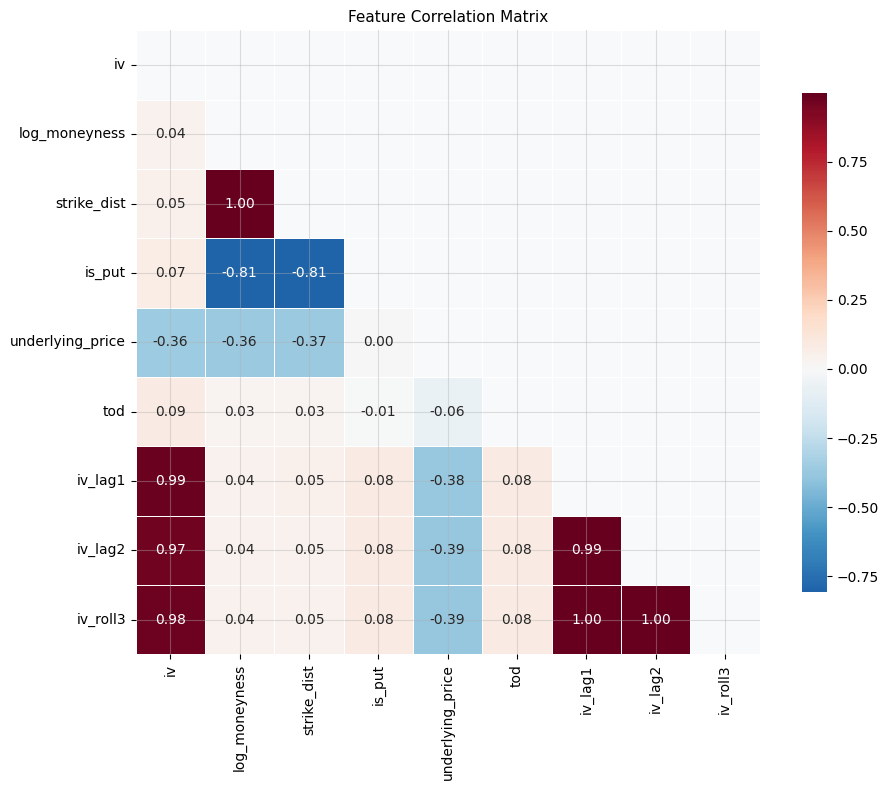

  → displayed 08_feature_correlation


In [ ]:

# =============================================================================
#  FEATURE CORRELATION ANALYSIS
# =============================================================================
print(f"\n{SEP}")
print(" FEATURE CORRELATION ANALYSIS")
print(SEP)

feat_df = obs.copy()
feat_df["log_moneyness"] = np.log(feat_df["strike"] / feat_df["underlying_price"])
feat_df["strike_dist"]   = feat_df["strike"] - feat_df["underlying_price"]
feat_df["is_put"]        = (feat_df["option_type"]=="PE").astype(int)
feat_df["tod"]           = feat_df["datetime"].dt.hour + feat_df["datetime"].dt.minute/60

feat_df = feat_df.sort_values(["datetime","strike"])
feat_df["iv_lag1"] = feat_df.groupby(["strike","option_type"])["iv"].shift(1)
feat_df["iv_lag2"] = feat_df.groupby(["strike","option_type"])["iv"].shift(2)
feat_df["iv_roll3"] = feat_df.groupby(["strike","option_type"])["iv"].transform(
    lambda x: x.ffill().shift(1).rolling(3, min_periods=1).mean()
)

corr_cols = ["iv","log_moneyness","strike_dist","is_put","underlying_price",
             "tod","iv_lag1","iv_lag2","iv_roll3"]
corr_data = feat_df[corr_cols].dropna()
corr_mat  = corr_data.corr()

print(f"\n  Correlation with IV (target):")
iv_corr = corr_mat["iv"].drop("iv").sort_values(key=abs, ascending=False)
for feat, corr_val in iv_corr.items():
    bar  = "█" * int(abs(corr_val)*30)
    sign = "+" if corr_val >= 0 else "-"
    print(f"    {feat:<22} {sign}{abs(corr_val):.4f}  {bar}")

print(f"\n  Key insight: lag features should have highest correlation with IV")
print(f"  if IV is persistent (autocorrelated) — confirms lag features are useful.")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_mat, ax=ax, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix")
show_plot("08_feature_correlation")


In [ ]:

# =============================================================================
# SPLINE QUALITY ASSESSMENT
# =============================================================================
print(f"\n{SEP}")
print(" SPLINE BASELINE QUALITY")
print(SEP)

# For each timestamp, fit spline and compute in-sample MSE on observed points
spline_errors = []
for ts, grp in obs.groupby("datetime"):
    for otype, sub in grp.groupby("option_type"):
        sub = sub.sort_values("log_moneyness")
        if len(sub) < 4: continue
        try:
            cs = CubicSpline(sub["log_moneyness"], sub["iv"])
            preds = cs(sub["log_moneyness"])
            err = np.mean((preds - sub["iv"].values)**2)
            spline_errors.append({"datetime":ts,"option_type":otype,
                                   "n_obs":len(sub),"mse":err})
        except: pass

if spline_errors:
    se_df = pd.DataFrame(spline_errors)
    print(f"\n  Spline in-sample MSE (fitted on observed points per timestamp):")
    print(f"    Mean  MSE : {se_df['mse'].mean():.8f}")
    print(f"    Median MSE: {se_df['mse'].median():.8f}")
    print(f"    Max   MSE : {se_df['mse'].max():.8f}")
    print(f"    Note: in-sample MSE ~0 is expected since spline interpolates.")
    print(f"    The real test is leave-one-out or cross-timestamp MSE.")

    # Leave-one-out spline MSE
    loo_errors = []
    sample_ts_loo = obs["datetime"].unique()[:30]
    for ts in sample_ts_loo:
        for otype in ["CE","PE"]:
            sub = obs[(obs["datetime"]==ts)&(obs["option_type"]==otype)].sort_values("log_moneyness")
            if len(sub) < 5: continue
            for i in range(len(sub)):
                train = sub.drop(sub.index[i])
                test  = sub.iloc[i]
                try:
                    cs = CubicSpline(train["log_moneyness"], train["iv"])
                    pred = float(cs(test["log_moneyness"]))
                    loo_errors.append((test["iv"] - pred)**2)
                except: pass
    if loo_errors:
        loo_mse = np.mean(loo_errors)
        print(f"\n  Spline leave-one-out MSE (first 30 timestamps): {loo_mse:.6f}")
        print(f"  Spline LOO RMSE: {np.sqrt(loo_mse):.4f}")
        print(f"  → This is the baseline your ML model needs to beat.")



─────────────────────────────────────────────────────────────────
SECTION 9 — SPLINE BASELINE QUALITY
─────────────────────────────────────────────────────────────────

  Spline in-sample MSE (fitted on observed points per timestamp):
    Mean  MSE : 0.00000000
    Median MSE: 0.00000000
    Max   MSE : 0.00000000
    Note: in-sample MSE ~0 is expected since spline interpolates.
    The real test is leave-one-out or cross-timestamp MSE.

  Spline leave-one-out MSE (first 30 timestamps): 0.000345
  Spline LOO RMSE: 0.0186
  → This is the baseline your ML model needs to beat.



─────────────────────────────────────────────────────────────────
SECTION 10 — MISSINGNESS PATTERN vs MONEYNESS
─────────────────────────────────────────────────────────────────

  Missing % by moneyness zone:
    DeepOTMput          20.0%  ████████
    OTMput              21.1%  ████████
    NearATMput          19.0%  ███████
    ATM                 19.8%  ███████
    NearATMcall         19.9%  ███████
    OTMcall             19.4%  ███████
    DeepOTMcall         50.0%  ████████████████████ ← highest missing

  Interpretation for modeling:
    ATM missing rate       : 19.8%  (easier to predict — more neighbors)
    Deep OTM missing rate  : 20.1%  (harder — sparse observations)
    → Spatial neighbor features most important for deep OTM predictions


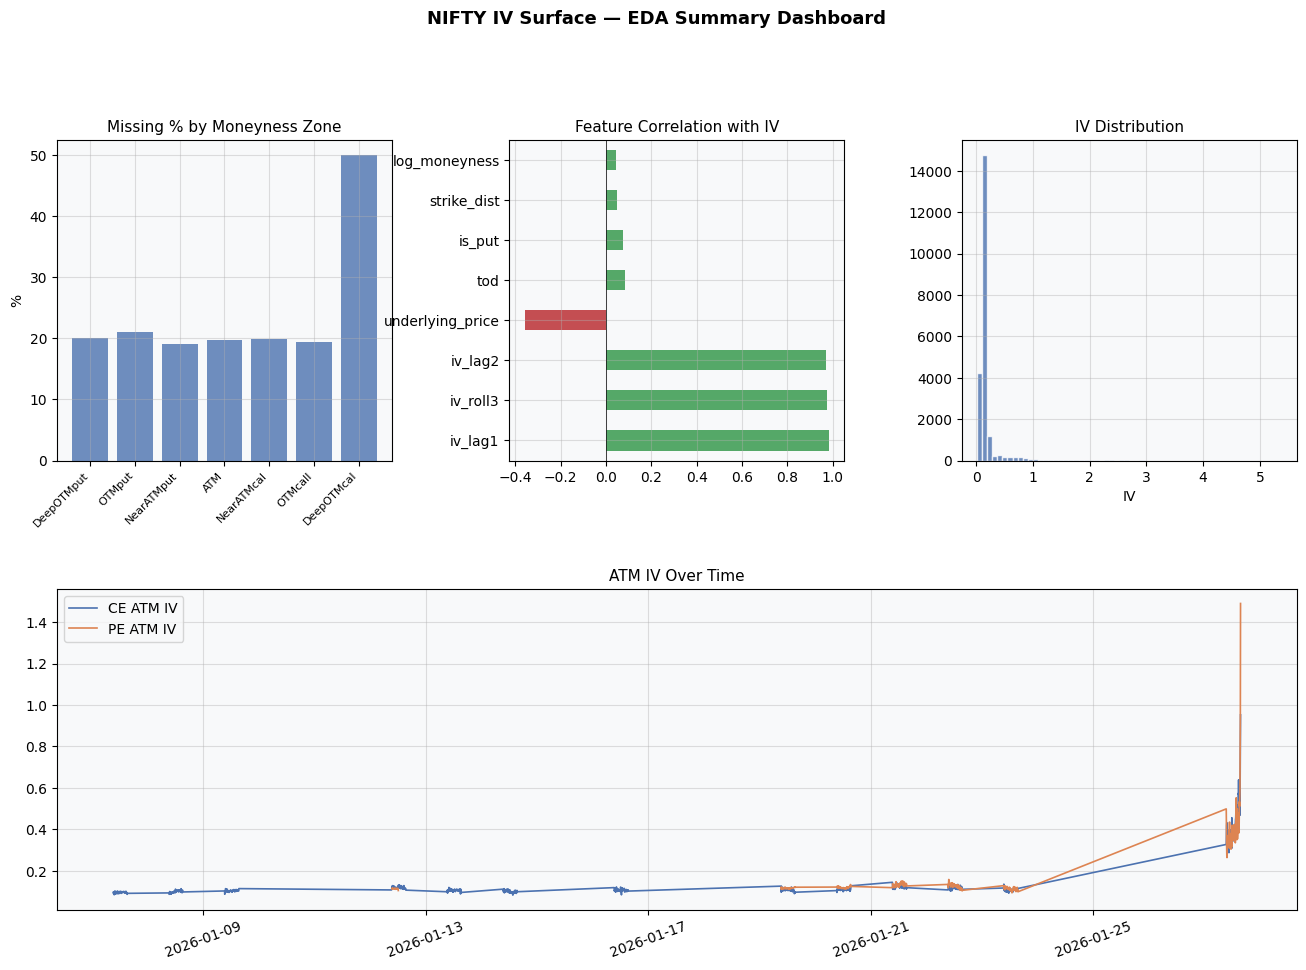

  → displayed 10_eda_summary_dashboard


In [ ]:

# =============================================================================
#  MISSINGNESS PATTERN ANALYSIS
# =============================================================================
print(f"\n{SEP}")
print("MISSINGNESS PATTERN vs MONEYNESS")
print(SEP)

miss_long = df_long.copy()
miss_long["is_missing"] = miss_long["iv"].isna()
miss_long["moneyness_zone"] = pd.cut(
    miss_long["log_moneyness"],
    bins=[-np.inf, -0.06, -0.03, -0.01, 0.01, 0.03, 0.06, np.inf],
    labels=["DeepOTMput","OTMput","NearATMput","ATM","NearATMcall","OTMcall","DeepOTMcall"]
)
miss_by_zone = miss_long.groupby("moneyness_zone")["is_missing"].mean()

print(f"\n  Missing % by moneyness zone:")
for zone, pct in miss_by_zone.items():
    bar = "█" * int(pct*40)
    flag = " ← highest missing" if pct == miss_by_zone.max() else ""
    print(f"    {str(zone):<18} {pct*100:5.1f}%  {bar}{flag}")

miss_by_otype = miss_long.groupby(["option_type","moneyness_zone"])["is_missing"].mean().unstack()
print(f"\n  Interpretation for modeling:")
deep_miss = miss_long[miss_long["moneyness_zone"].isin(["DeepOTMput","DeepOTMcall"])]["is_missing"].mean()
atm_miss  = miss_long[miss_long["moneyness_zone"]=="ATM"]["is_missing"].mean()
print(f"    ATM missing rate       : {atm_miss*100:.1f}%  (easier to predict — more neighbors)")
print(f"    Deep OTM missing rate  : {deep_miss*100:.1f}%  (harder — sparse observations)")
print(f"    → Spatial neighbor features most important for deep OTM predictions")

# Figure combined summary
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(len(miss_by_zone)), miss_by_zone.values*100, color="#4C72B0", alpha=0.8)
ax1.set_xticks(range(len(miss_by_zone)))
ax1.set_xticklabels([str(z)[:10] for z in miss_by_zone.index], rotation=45, ha="right", fontsize=8)
ax1.set_title("Missing % by Moneyness Zone"); ax1.set_ylabel("%")

ax2 = fig.add_subplot(gs[0, 1])
iv_corr.plot(kind="barh", ax=ax2, color=["#55A868" if v>0 else "#C44E52" for v in iv_corr])
ax2.set_title("Feature Correlation with IV"); ax2.axvline(0, color="black", lw=0.5)

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(iv_vals, bins=60, color="#4C72B0", alpha=0.8, edgecolor="white")
ax3.set_title("IV Distribution"); ax3.set_xlabel("IV")

ax4 = fig.add_subplot(gs[1, :])
for col, color in zip(["CE","PE"] if "CE" in atm_iv_ts.columns and "PE" in atm_iv_ts.columns else [],
                      ["#4C72B0","#DD8452"]):
    if col in atm_iv_ts.columns:
        ax4.plot(atm_iv_ts.index, atm_iv_ts[col], label=f"{col} ATM IV", color=color, lw=1.2)
ax4.set_title("ATM IV Over Time"); ax4.legend(); ax4.tick_params(axis='x', rotation=20)
fig.suptitle("NIFTY IV Surface — EDA Summary Dashboard", fontsize=13, fontweight="bold", y=1.01)
show_plot("10_eda_summary_dashboard")
